## Ćw. 7 Sieci rekurencyjne RNN (LSTM) i ich zastosowania. Część 1

Na ćwiczeniach 7 poznamy przykłady zastosowania sieci LSTM.
1. Przewidywania wartości szeregów czasowych (Ćw.7a, Ćw.7b).
2. Klasyfikacji obrazów na przykładzie MNIST(Ćw.7c)
3. Prognozowanie ruchu kwadratu (Ćw. 7d)

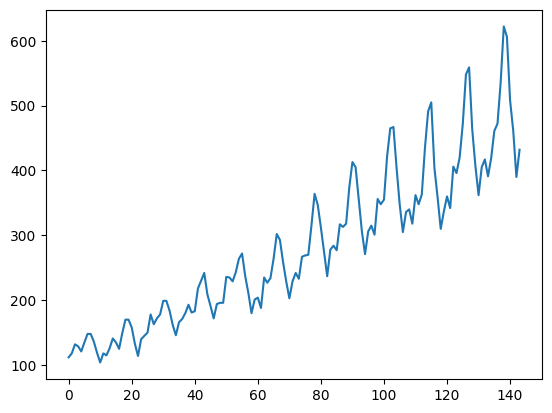

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import matplotlib.pyplot as plt

df = pd.read_csv('https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv')
timeseries = df[["Passengers"]].values.astype('float32')
plt.plot(timeseries)
plt.show()

In [ ]:
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


Nasze dane to szereg czasowy, który ma 144 kroki czasowe. Na wykresie widać, że istnieje trend wzrostowy.
W zbiorze danych występuje również pewna okresowość, która odpowiada okresowi letnich wakacji na półkuli północnej.
 Zazwyczaj szereg czasowy powinien być „detrendowany”, aby usunąć składnik trendu liniowego i znormalizować przed przetworzeniem. Dla uproszczenia ten krok pomijamy.
Aby zademonstrować moc predykcyjną  modelu LSTM, szereg czasowy został podzielony na zestawy uczące i testowe.
 W przeciwieństwie do innych zbiorów danych, zwykle dane szeregów czasowych są dzielone bez tasowania.
Oznacza to, że zestaw treningowy to pierwsza część szeregu czasowego, a pozostała część zostanie wykorzystana jako zestaw testowy. Można to łatwo zrobić na tablicy NumPy:

Klasycznym podejściem do analizy i prognozowania szeregów czasowych jest podejście ekonometryczne. [Przykłady modeli ekonometrycznych szeregów czasowych](https://el.us.edu.pl/ekonofizyka/index.php/Analiza_Szereg%C3%B3w_Czasowych/Modelowanie_szereg%C3%B3w_czasowych)

https://machinelearningmastery.com/lstm-for-time-series-prediction-in-pytorch/

In [ ]:
len(timeseries)


144

In [ ]:
timeseries[:10]

array([[112.],
       [118.],
       [132.],
       [129.],
       [121.],
       [135.],
       [148.],
       [148.],
       [136.],
       [119.]], dtype=float32)

In [ ]:

# train-test split for time series
train_size = int(len(timeseries) * 0.67)
test_size = len(timeseries) - train_size
train, test = timeseries[:train_size], timeseries[train_size:]

def create_dataset(dataset, lookback):
    """Przekształcenie szeregu czasowego w zestaw danych predykcyjnych

    Args:
        dataset: Tablica numpy szeregów czasowych, pierwszy wymiar to kroki czasowe
        lookback: Rozmiar okna do przewidywania
    """
    X, y = [], []
    for i in range(len(dataset)-lookback):
        feature = dataset[i:i+lookback]
        target = dataset[i+1:i+lookback+1]
        X.append(feature)
        y.append(target)
    return torch.tensor(X), torch.tensor(y)

lookback = 4
X_train, y_train = create_dataset(train, lookback=lookback)
X_test, y_test = create_dataset(test, lookback=lookback)



<ipython-input-3-e6d75f4f4039>:19: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  return torch.tensor(X), torch.tensor(y)


In [ ]:
X_train.shape

torch.Size([92, 4, 1])

Bardziej skomplikowanym problemem jest to, w jaki sposób sieć ma przewidywać szereg czasowy.
Zazwyczaj przewidywanie szeregów czasowych odbywa się w oknie. Oznacza to, że biorąc pod uwagę dane od czasu t - w do
t, użytkownik jest proszony o prognozowanie dla czasu t + 1 (lub głębiej w przyszłość). Rozmiar okna
w określa, ile danych można wziąć pod uwagę podczas prognozowania. Jest to
zwane również okresem wstecznym

In [ ]:
display(pd.DataFrame(X_train[:,:,0]))

,0,1,2,3
0,112.0,118.0,132.0,129.0
1,118.0,132.0,129.0,121.0
2,132.0,129.0,121.0,135.0
3,129.0,121.0,135.0,148.0
4,121.0,135.0,148.0,148.0
...,...,...,...,...
87,313.0,318.0,374.0,413.0
88,318.0,374.0,413.0,405.0
89,374.0,413.0,405.0,355.0
90,413.0,405.0,355.0,306.0


In [ ]:
X_train[0]

tensor([[112.],
        [118.],
        [132.],
        [129.]])

In [ ]:
X_train[1]

tensor([[118.],
        [132.],
        [129.],
        [121.]])

In [ ]:
y_train[0]

tensor([[118.],
        [132.],
        [129.],
        [121.]])

In [ ]:
y_train[:, -1, :]

tensor([[121.],
        [135.],
        [148.],
        [148.],
        [136.],
        [119.],
        [104.],
        [118.],
        [115.],
        [126.],
        [141.],
        [135.],
        [125.],
        [149.],
        [170.],
        [170.],
        [158.],
        [133.],
        [114.],
        [140.],
        [145.],
        [150.],
        [178.],
        [163.],
        [172.],
        [178.],
        [199.],
        [199.],
        [184.],
        [162.],
        [146.],
        [166.],
        [171.],
        [180.],
        [193.],
        [181.],
        [183.],
        [218.],
        [230.],
        [242.],
        [209.],
        [191.],
        [172.],
        [194.],
        [196.],
        [196.],
        [236.],
        [235.],
        [229.],
        [243.],
        [264.],
        [272.],
        [237.],
        [211.],
        [180.],
        [201.],
        [204.],
        [188.],
        [235.],
        [227.],
        [234.],
        [264.],
        

In [ ]:
X_test[1:5]
len(X_test)
X_test.shape

torch.Size([44, 4, 1])

In [ ]:
X_test[1:5]

tensor([[[301.],
         [356.],
         [348.],
         [355.]],

        [[356.],
         [348.],
         [355.],
         [422.]],

        [[348.],
         [355.],
         [422.],
         [465.]],

        [[355.],
         [422.],
         [465.],
         [467.]]])

In [ ]:
y_test[1:5]

tensor([[[356.],
         [348.],
         [355.],
         [422.]],

        [[348.],
         [355.],
         [422.],
         [465.]],

        [[355.],
         [422.],
         [465.],
         [467.]],

        [[422.],
         [465.],
         [467.],
         [404.]]])

In [ ]:
class AirModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=50, num_layers=1, batch_first=True)
        self.linear = nn.Linear(50, 1)
    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.linear(x)
        return x

model = AirModel()
optimizer = optim.Adam(model.parameters())
loss_fn = nn.MSELoss()
loader = data.DataLoader(data.TensorDataset(X_train, y_train), shuffle=True, batch_size=8)

n_epochs = 2000
for epoch in range(n_epochs):
    model.train()
    for X_batch, y_batch in loader:
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    # testowanie
    if epoch % 100 != 0:
        continue
    model.eval()
    with torch.no_grad():
        y_pred = model(X_train)
        train_rmse = np.sqrt(loss_fn(y_pred, y_train))
        y_pred = model(X_test)
        test_rmse = np.sqrt(loss_fn(y_pred, y_test))
    print("Epoch %d: train RMSE %.4f, test RMSE %.4f" % (epoch, train_rmse, test_rmse))

with torch.no_grad():
    # przesunięcie przewidywań na próbie uczącej na potrzeby wykresu
    train_plot = np.ones_like(timeseries) * np.nan
    y_pred = model(X_train)
    y_pred = y_pred[:, -1, :]
    train_plot[lookback:train_size] = model(X_train)[:, -1, :]
    # przesunięcie przewidywań na próbie testowej na potrzeby wykresu
    test_plot = np.ones_like(timeseries) * np.nan
    test_plot[train_size+lookback:len(timeseries)] = model(X_test)[:, -1, :]



<ipython-input-13-c54908ca5ba7>:31: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  train_rmse = np.sqrt(loss_fn(y_pred, y_train))
<ipython-input-13-c54908ca5ba7>:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  test_rmse = np.sqrt(loss_fn(y_pred, y_test))


Epoch 0: train RMSE 226.1169, test RMSE 425.3639
Epoch 100: train RMSE 178.9057, test RMSE 375.8623
Epoch 200: train RMSE 142.8492, test RMSE 336.5033
Epoch 300: train RMSE 113.2065, test RMSE 301.5336
Epoch 400: train RMSE 91.0317, test RMSE 271.0354
Epoch 500: train RMSE 68.5550, test RMSE 237.2276
Epoch 600: train RMSE 53.9828, test RMSE 209.6284
Epoch 700: train RMSE 44.0302, test RMSE 185.6573
Epoch 800: train RMSE 35.9495, test RMSE 164.0842
Epoch 900: train RMSE 31.0314, test RMSE 145.7087
Epoch 1000: train RMSE 27.4209, test RMSE 130.4703
Epoch 1100: train RMSE 25.3467, test RMSE 118.4740
Epoch 1200: train RMSE 23.8395, test RMSE 107.6838
Epoch 1300: train RMSE 23.1589, test RMSE 99.5329
Epoch 1400: train RMSE 21.4195, test RMSE 94.5123
Epoch 1500: train RMSE 20.9284, test RMSE 89.4279
Epoch 1600: train RMSE 20.3597, test RMSE 85.2367
Epoch 1700: train RMSE 20.3566, test RMSE 81.9395
Epoch 1800: train RMSE 20.0318, test RMSE 79.7174
Epoch 1900: train RMSE 19.4895, test RMSE 77.

<ipython-input-13-c54908ca5ba7>:41: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  train_plot[lookback:train_size] = model(X_train)[:, -1, :]
<ipython-input-13-c54908ca5ba7>:44: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  test_plot[train_size+lookback:len(timeseries)] = model(X_test)[:, -1, :]


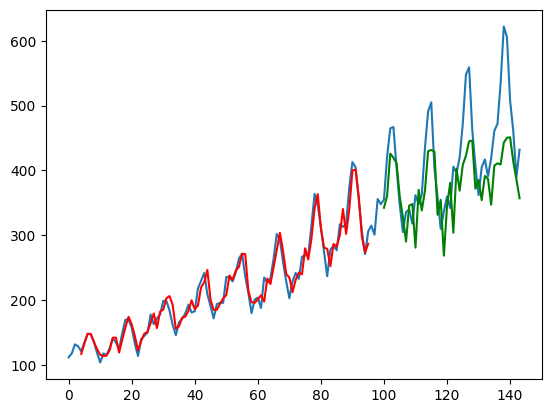

In [ ]:
import matplotlib.pyplot as plt
plt.plot(timeseries)
plt.plot(train_plot, c='r')
plt.plot(test_plot, c='g')
plt.show()
